# 01 — RNG Stream Partitioning

**Invariant proved:** Reproducibility Infrastructure (RNG Partitioning)  
**Module built:** `sdk/core/rng.py` — `RNGPartitioner`, `RNGStreams`

The RNG partitioner is the foundation of the entire SDK. It uses `numpy.random.SeedSequence.spawn()` to create 5 statistically independent RNG streams:

| Stream | Used by | Purpose |
|--------|---------|---------|
| `population` | `create_population()` | Initial state generation |
| `temporal` | `step()` | Domain physics evolution |
| `prediction` | `predict()` | ML model noise |
| `intervention` | `intervene()` | Randomized assignment |
| `outcomes` | `measure()` | Outcome generation |

**Why this matters:** In branched counterfactual simulation, the factual and counterfactual branches must experience identical stochastic evolution — they should diverge only where intervention changed state. If all randomness flows through a single RNG, consuming draws for intervention on the factual branch desynchronizes the temporal draws on the counterfactual branch. Stream partitioning prevents this.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from sdk.core.rng import RNGPartitioner, RNGStreams

## 1. Reproducibility: Same Seed = Same Draws

The most basic requirement: given the same master seed, every stream must produce identical sequences across runs.

In [2]:
# Create two partitioners with the same seed
p1 = RNGPartitioner(master_seed=42)
p2 = RNGPartitioner(master_seed=42)

s1 = p1.create_streams()
s2 = p2.create_streams()

# Verify every stream is reproducible
for name in RNGPartitioner.STREAM_NAMES:
    draws_a = getattr(s1, name).random(10)
    draws_b = getattr(s2, name).random(10)
    match = np.array_equal(draws_a, draws_b)
    print(f"{name:15s} reproducible: {match}  first 3 values: {draws_a[:3].round(4)}")
    assert match, f"Stream '{name}' is not reproducible!"

print("\nAll streams reproducible across runs.")

population      reproducible: True  first 3 values: [0.9167 0.911  0.8766]
temporal        reproducible: True  first 3 values: [0.4675 0.0464 0.5955]
prediction      reproducible: True  first 3 values: [0.0712 0.7102 0.0718]
intervention    reproducible: True  first 3 values: [0.7639 0.9713 0.713 ]
outcomes        reproducible: True  first 3 values: [0.0176 0.9918 0.8324]

All streams reproducible across runs.


## 2. Stream Independence: Consuming One Stream Does Not Affect Another

This is the critical property for branched simulation. If the factual branch consumes 1000 intervention draws between two temporal draws, the temporal output must be unchanged compared to a run with zero intervention consumption.

In [3]:
# Run A: consume intervention stream between temporal draws
sa = RNGPartitioner(42).create_streams()
temporal_before_a = sa.temporal.random(5)
sa.intervention.random(1000)  # heavy consumption of a different stream
temporal_after_a = sa.temporal.random(5)

# Run B: no intervention consumption
sb = RNGPartitioner(42).create_streams()
temporal_before_b = sb.temporal.random(5)
# (no intervention draws)
temporal_after_b = sb.temporal.random(5)

print("Temporal draws BEFORE intervention consumption:")
print(f"  Run A: {temporal_before_a.round(6)}")
print(f"  Run B: {temporal_before_b.round(6)}")
print(f"  Match: {np.array_equal(temporal_before_a, temporal_before_b)}")
print()
print("Temporal draws AFTER 1000 intervention draws on Run A:")
print(f"  Run A: {temporal_after_a.round(6)}")
print(f"  Run B: {temporal_after_b.round(6)}")
print(f"  Match: {np.array_equal(temporal_after_a, temporal_after_b)}")

assert np.array_equal(temporal_before_a, temporal_before_b)
assert np.array_equal(temporal_after_a, temporal_after_b)
print("\nStream independence confirmed.")

Temporal draws BEFORE intervention consumption:
  Run A: [0.467491 0.046449 0.59551  0.107275 0.974896]
  Run B: [0.467491 0.046449 0.59551  0.107275 0.974896]
  Match: True

Temporal draws AFTER 1000 intervention draws on Run A:
  Run A: [0.465822 0.835056 0.08304  0.625384 0.177951]
  Run B: [0.465822 0.835056 0.08304  0.625384 0.177951]
  Match: True

Stream independence confirmed.


## 3. Cross-Stream Correlation

All 5 streams should be statistically independent. We verify by drawing 10,000 samples from each and computing the pairwise correlation matrix.

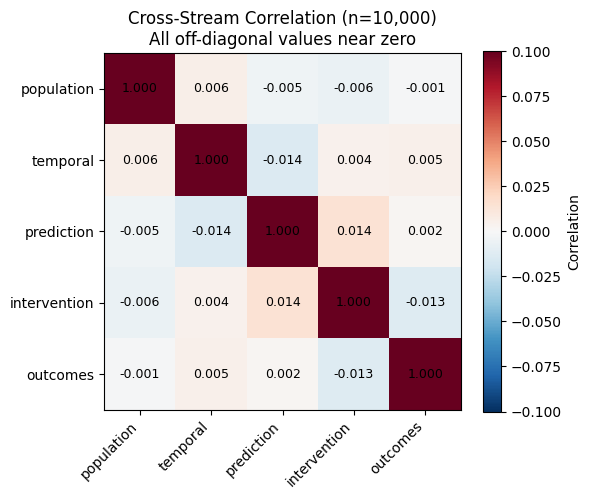

Maximum off-diagonal |correlation|: 0.0143
All cross-stream correlations < 0.05


In [4]:
n = 10_000
streams = RNGPartitioner(42).create_streams()
names = RNGPartitioner.STREAM_NAMES
draws = np.column_stack([getattr(streams, name).random(n) for name in names])

corr_matrix = np.corrcoef(draws.T)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-0.1, vmax=0.1)
ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{corr_matrix[i, j]:.3f}", ha='center', va='center', fontsize=9)
plt.colorbar(im, label='Correlation')
ax.set_title(f'Cross-Stream Correlation (n={n:,})\nAll off-diagonal values near zero')
plt.tight_layout()
plt.show()

# Verify all off-diagonal correlations are small
mask = ~np.eye(len(names), dtype=bool)
max_corr = np.abs(corr_matrix[mask]).max()
print(f"Maximum off-diagonal |correlation|: {max_corr:.4f}")
assert max_corr < 0.05, f"Cross-stream correlation too high: {max_corr}"
print("All cross-stream correlations < 0.05")

## 4. Fork Equivalence

`fork()` creates a new partitioner from the same master seed. The forked streams are independent Generator objects (no shared mutable state) but produce identical values when consumed in the same order. This is what enables branched counterfactual simulation.

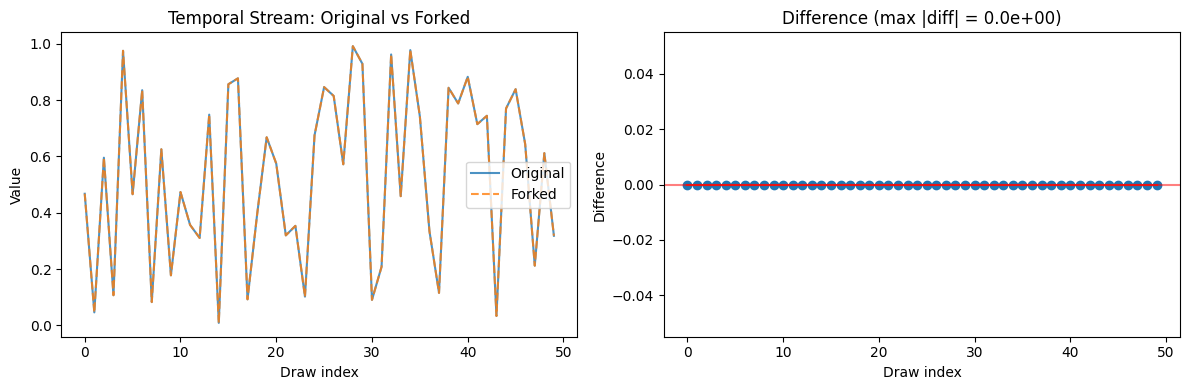

Fork produces identical starting streams.


In [5]:
p = RNGPartitioner(42)
original = p.create_streams()
forked = p.fork().create_streams()

# Both produce the same temporal draws
n_draws = 50
orig_temporal = RNGPartitioner(42).create_streams().temporal.random(n_draws)
fork_temporal = RNGPartitioner(42).fork().create_streams().temporal.random(n_draws)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Trace plot
axes[0].plot(orig_temporal, label='Original', alpha=0.8)
axes[0].plot(fork_temporal, '--', label='Forked', alpha=0.8)
axes[0].set_xlabel('Draw index')
axes[0].set_ylabel('Value')
axes[0].set_title('Temporal Stream: Original vs Forked')
axes[0].legend()

# Difference
diff = orig_temporal - fork_temporal
axes[1].stem(range(len(diff)), diff)
axes[1].set_xlabel('Draw index')
axes[1].set_ylabel('Difference')
axes[1].set_title(f'Difference (max |diff| = {np.abs(diff).max():.1e})')
axes[1].axhline(y=0, color='r', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()

assert np.array_equal(orig_temporal, fork_temporal)
print("Fork produces identical starting streams.")

In [6]:
# Verify independence: consuming original doesn't affect forked
p = RNGPartitioner(42)
orig = p.create_streams()
fork_streams = p.fork().create_streams()

# Consume original temporal heavily
orig.temporal.random(10_000)

# Forked still matches a fresh creation
fresh = RNGPartitioner(42).create_streams()
fork_draws = fork_streams.temporal.random(20)
fresh_draws = fresh.temporal.random(20)

assert np.array_equal(fork_draws, fresh_draws)
print("Forked streams are independent objects (no shared mutable state).")

Forked streams are independent objects (no shared mutable state).


## Key Insights

1. **SeedSequence.spawn()** produces statistically independent child generators — no cross-stream interference regardless of consumption patterns.
2. **Reproducibility** is guaranteed: same master seed always produces the same streams.
3. **fork()** creates a new partitioner with the same master seed, yielding identical starting streams as independent Generator objects.
4. These properties together enable the branched counterfactual engine: factual and counterfactual branches get identical temporal/outcome streams, diverging only where intervention modifies state.

**Next:** [02_state_and_clone.ipynb](02_state_and_clone.ipynb) — mutation isolation for branched state.